# Phase 2: Gait Asymmetry & Compensatory Mechanisms

## Project: OrthoAnalytics - Clinical Gait Study

In Phase 1, we established that bracing significantly reduces ROM in the affected limb. In this phase, we analyze how the **contralateral (unbraced) limb** compensates for this restriction.

### Objectives:
1. **Bilateral Comparison**: Plot Left vs. Right kinematics under braced conditions.
2. **Symmetry Index (SI)**: Quantify the deviation between limbs.
3. **Energy/Work Analysis**: Estimate changes in movement intensity to detect over-compensation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# Load data
data_path = "../data/raw/gait.csv"
df = pd.read_csv(data_path)

# Mapping
condition_map = {1: 'Unbraced', 2: 'Knee-Braced', 3: 'Ankle-Braced'}
joint_map = {1: 'Ankle', 2: 'Knee', 3: 'Hip'}
leg_map = {1: 'Left', 2: 'Right'}

df['condition_name'] = df['condition'].map(condition_map)
df['joint_name'] = df['joint'].map(joint_map)
df['leg_name'] = df['leg'].map(leg_map)

### 1. Visualizing Bilateral Asymmetry (Knee-Braced)
We compare the Left (unbraced) and Right (braced) legs for a single subject during the Knee-Braced condition.

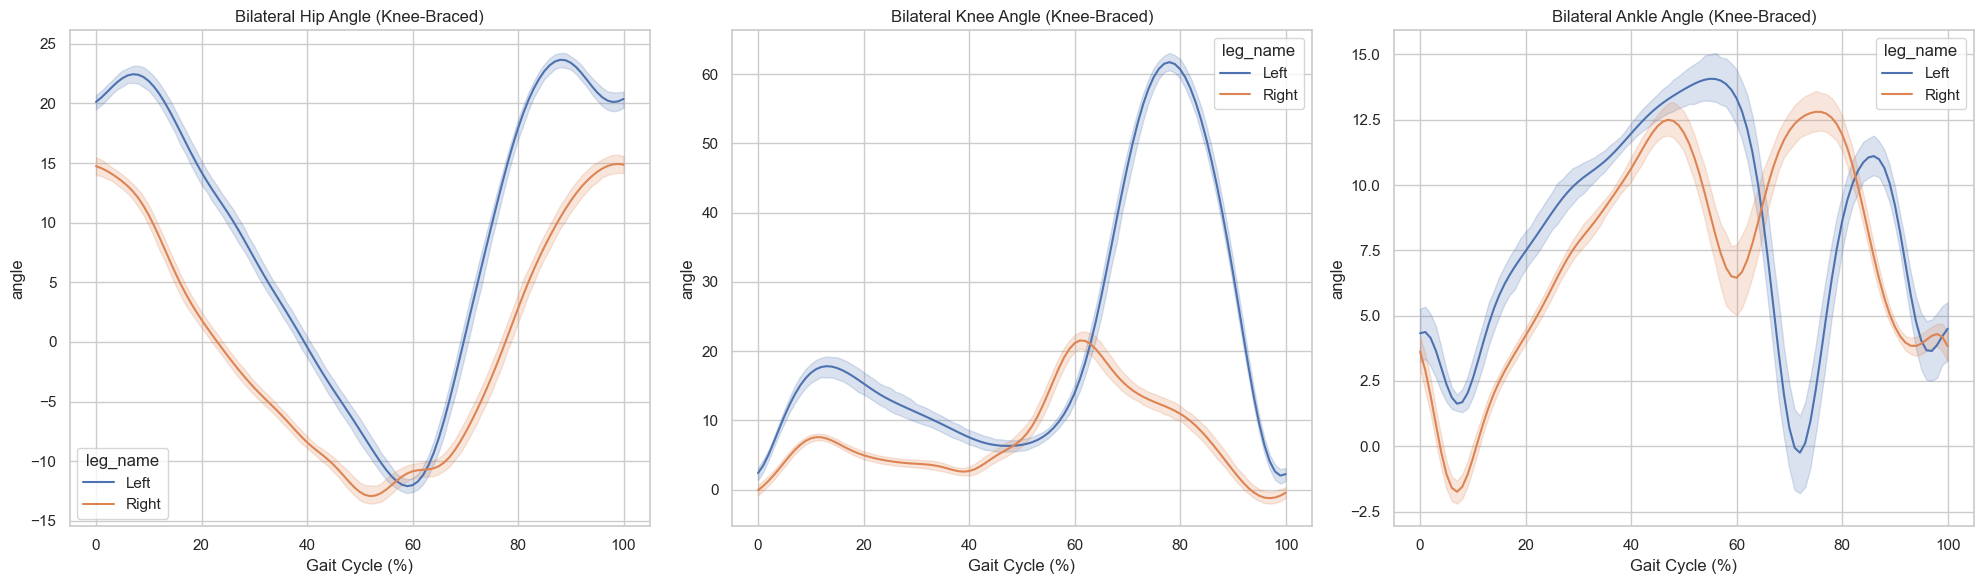

In [2]:
knee_braced_subj1 = df[(df['subject'] == 1) & (df['condition'] == 2)]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, joint in enumerate(['Hip', 'Knee', 'Ankle']):
    sns.lineplot(data=knee_braced_subj1[knee_braced_subj1['joint_name'] == joint], 
                 x='time', y='angle', hue='leg_name', ax=axes[i])
    axes[i].set_title(f'Bilateral {joint} Angle (Knee-Braced)')
    axes[i].set_xlabel('Gait Cycle (%)')

plt.tight_layout()
plt.show()

### 2. Symmetry Index (SI) Calculation
We use the Gait Symmetry Index formula:
$$SI = \frac{2(X_R - X_L)}{X_R + X_L} \times 100%$$
Where $X$ is the Mean ROM. An SI of 0% indicates perfect symmetry.

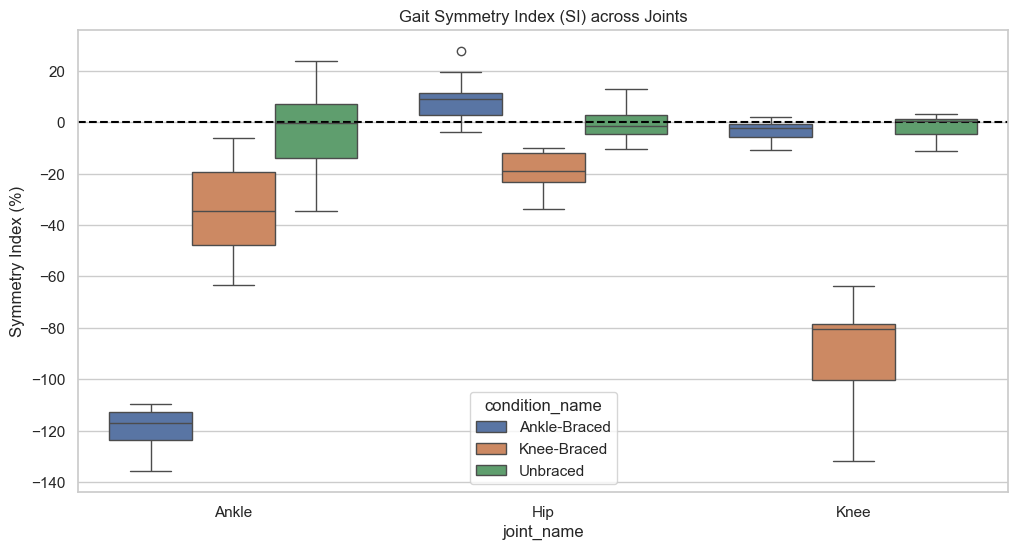

Positive SI = Right Leg Dominance | Negative SI = Left Leg Dominance


In [3]:
# Calculate ROM for each leg/subject/condition
rom_bilateral = df.groupby(['subject', 'condition_name', 'joint_name', 'leg_name'])['angle'].agg(lambda x: x.max() - x.min()).reset_index()

# Pivot to have Left and Right in columns
rom_pivot = rom_bilateral.pivot(index=['subject', 'condition_name', 'joint_name'], columns='leg_name', values='angle').reset_index()

# Calculate SI
rom_pivot['SI'] = (2 * (rom_pivot['Right'] - rom_pivot['Left']) / (rom_pivot['Right'] + rom_pivot['Left'])) * 100

plt.figure(figsize=(12, 6))
sns.boxplot(data=rom_pivot, x='joint_name', y='SI', hue='condition_name')
plt.axhline(0, color='black', linestyle='--')
plt.title('Gait Symmetry Index (SI) across Joints')
plt.ylabel('Symmetry Index (%)')
plt.show()

print("Positive SI = Right Leg Dominance | Negative SI = Left Leg Dominance")

### 3. Statistical Validation of Asymmetry
Is the asymmetry statistically significant in the Knee-Braced condition compared to Baseline?

In [4]:
from scipy.stats import ttest_rel

for joint in ['Ankle', 'Knee', 'Hip']:
    knee_data = rom_pivot[(rom_pivot['condition_name'] == 'Knee-Braced') & (rom_pivot['joint_name'] == joint)]
    t_stat, p_val = ttest_rel(knee_data['Left'], knee_data['Right'])
    print(f"{joint} (Knee-Braced) - Paired t-test: p-value = {p_val:.4f} {'*' if p_val < 0.05 else ''}")

Ankle (Knee-Braced) - Paired t-test: p-value = 0.0003 *
Knee (Knee-Braced) - Paired t-test: p-value = 0.0000 *
Hip (Knee-Braced) - Paired t-test: p-value = 0.0001 *
